# Notebook: Redes Neuronales Convolucionales (CNN) para FashionMNIST

Este notebook mantiene la estructura del pipeline proporcionado en clase y adapta el problema a
**FashionMNIST**, utilizando únicamente dos clases:

- **Sneaker**
- **Ankle boot**

El objetivo es construir una CNN desde cero, analizar sus curvas de entrenamiento, aplicar
Data Augmentation, utilizar Transfer Learning con ResNet18 y visualizar Grad-CAM.

Para la CNN desde cero se utilizarán **15 épocas**, de modo que sea posible observar la evolución
de la pérdida sin que el entrenamiento sea demasiado lento.

## 1. ¿Qué es una CNN y por qué se usa en imágenes?

Una **CNN (Convolutional Neural Network)** es un tipo de red neuronal diseñada para trabajar con
datos que tienen estructura espacial, como imágenes.

En una imagen, los píxeles cercanos suelen estar relacionados. Las CNN aprovechan esta estructura
mediante filtros convolucionales que aprenden patrones como bordes, texturas y formas.

### Componentes principales

- **Convolución (`Conv2d`)**: extrae características visuales.
- **ReLU**: introduce no linealidad.
- **Pooling (`MaxPool2d`)**: reduce el tamaño espacial.
- **Clasificador final**: utiliza las características aprendidas para decidir la clase.

En este ejercicio la CNN aprenderá a diferenciar imágenes de **Sneaker** y **Ankle boot**.

## 2. Preparación del entorno

Usaremos **PyTorch** y `torchvision` para construir los modelos y descargar FashionMNIST.

In [1]:
import sys
import subprocess

packages = [
    "torch",
    "torchvision",
    "numpy",
    "matplotlib",
    "scikit-learn",
    "tqdm"
]

for p in packages:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        p
    ])

## 3. Cargar el dataset FashionMNIST

FashionMNIST contiene imágenes en escala de grises de **28 × 28 píxeles**.

El dataset original tiene 10 clases, pero para mantener el problema como una clasificación
binaria se utilizarán solamente:

- Clase original 7: **Sneaker**
- Clase original 9: **Ankle boot**

Estas clases serán remapeadas:

- `0 = Sneaker`
- `1 = Ankle boot`

In [2]:
import random
import numpy as np
import torch
import matplotlib.pyplot as plt

import torchvision.transforms as T
from torchvision.datasets import FashionMNIST

from PIL import Image

from torch.utils.data import (
    Dataset,
    DataLoader,
    Subset
)

from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [3]:
class BinaryFashionMNIST(Dataset):
    def __init__(
        self,
        root="./data",
        train=True,
        transform=None,
        download=True
    ):
        base_dataset = FashionMNIST(
            root=root,
            train=train,
            download=download
        )

        selected_classes = [7, 9]

        mask = (
            (base_dataset.targets == selected_classes[0]) |
            (base_dataset.targets == selected_classes[1])
        )

        self.data = base_dataset.data[mask]

        original_targets = base_dataset.targets[mask]

        # Remapeo:
        # 7 -> 0 (Sneaker)
        # 9 -> 1 (Ankle boot)
        self.targets = torch.where(
            original_targets == 7,
            torch.tensor(0),
            torch.tensor(1)
        )

        self.transform = transform

        self.classes = [
            "Sneaker",
            "Ankle boot"
        ]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):

        # Convertir tensor a imagen PIL
        # Pillow detecta automáticamente escala de grises
        image = Image.fromarray(
            self.data[idx].numpy()
        )

        label = int(
            self.targets[idx].item()
        )

        if self.transform is not None:
            image = self.transform(image)

        return image, label

In [4]:
transform_basic = T.Compose([
    T.ToTensor()
])

full_train_dataset = BinaryFashionMNIST(
    train=True,
    transform=transform_basic,
    download=True
)

test_dataset = BinaryFashionMNIST(
    train=False,
    transform=transform_basic,
    download=True
)

indices = np.arange(
    len(full_train_dataset)
)

targets = np.array([
    full_train_dataset.targets[i].item()
    for i in range(
        len(full_train_dataset)
    )
])

train_idx, val_idx = train_test_split(
    indices,
    test_size=0.20,
    random_state=SEED,
    stratify=targets
)

train_dataset = Subset(
    full_train_dataset,
    train_idx
)

val_dataset = Subset(
    full_train_dataset,
    val_idx
)

print(
    "Train:",
    len(train_dataset)
)

print(
    "Validation:",
    len(val_dataset)
)

print(
    "Test:",
    len(test_dataset)
)

print(
    "Clases:",
    full_train_dataset.classes
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 170kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.19MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 22.5MB/s]


Train: 9600
Validation: 2400
Test: 2000
Clases: ['Sneaker', 'Ankle boot']


### 3.1. Visualizar ejemplos

Una buena práctica inicial es observar ejemplos del dataset para comprobar el formato de las
imágenes y las etiquetas.

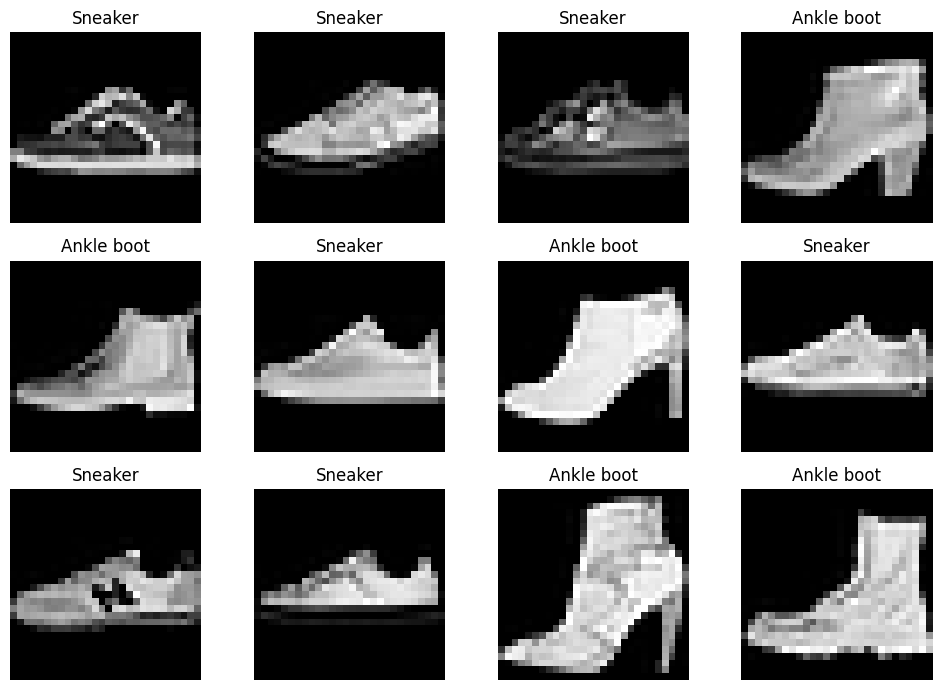

In [5]:
class_names = [
    "Sneaker",
    "Ankle boot"
]

def show_batch(
    dataset,
    n=12
):
    plt.figure(
        figsize=(10, 7)
    )

    for i in range(n):
        x, y = dataset[i]

        plt.subplot(
            3,
            4,
            i + 1
        )

        plt.imshow(
            x.squeeze(0),
            cmap="gray"
        )

        plt.title(
            class_names[y]
        )

        plt.axis("off")

    plt.tight_layout()
    plt.show()


show_batch(
    train_dataset,
    n=12
)

## 4. Preparar DataLoaders y device

Los **DataLoaders** manejan los lotes de imágenes y el `shuffle`.

El **device** permite utilizar GPU cuando está disponible.

Se utiliza `num_workers=0` para evitar errores de workers en Google Colab.

In [6]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

device

device(type='cuda')

In [7]:
batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

xb, yb = next(
    iter(train_loader)
)

print(
    "Batch imágenes:",
    xb.shape
)

print(
    "Batch etiquetas:",
    yb.shape
)

Batch imágenes: torch.Size([128, 1, 28, 28])
Batch etiquetas: torch.Size([128])


## 5. Modelo 1: CNN entrenada desde cero

Construiremos una CNN básica siguiendo la estructura del pipeline original:

- Bloques convolucionales.
- ReLU.
- Max Pooling.
- Clasificador final.

Como FashionMNIST utiliza imágenes en escala de grises, la primera convolución recibe
**1 canal de entrada**.

In [8]:
import torch.nn as nn
import torch.nn.functional as F

num_classes = 2


class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(

            # Primera capa convolucional
            nn.Conv2d(
                in_channels=1,
                out_channels=16,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Segunda capa convolucional
            nn.Conv2d(
                in_channels=16,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d(
                (1, 1)
            )
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(
                32,
                num_classes
            )
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model_scratch = SimpleCNN(
    num_classes=num_classes
).to(device)

model_scratch

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32, out_features=2, bias=True)
  )
)

### 5.1. Funciones de entrenamiento y evaluación

Se evaluarán:

- **Accuracy**
- **ROC-AUC**
- **Matriz de confusión**
- **Precision / Recall / F1**

Además, se calculará la **pérdida de validación**, necesaria para construir la curva solicitada
por el profesor.

In [9]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)


def logits_to_probs(logits):
    if logits.shape[1] == 1:
        return torch.sigmoid(
            logits
        ).squeeze(1)

    return torch.softmax(
        logits,
        dim=1
    )[:, 1]


@torch.no_grad()
def evaluate(
    model,
    loader
):
    model.eval()

    all_labels = []
    all_probs = []
    all_preds = []

    for x, y in loader:

        x = x.to(
            device
        )

        y = y.to(
            device
        ).long()

        logits = model(x)

        probs = logits_to_probs(
            logits
        )

        preds = (
            probs >= 0.5
        ).long()

        all_labels.append(
            y.cpu().numpy()
        )

        all_probs.append(
            probs.cpu().numpy()
        )

        all_preds.append(
            preds.cpu().numpy()
        )

    y_true = np.concatenate(
        all_labels
    )

    y_prob = np.concatenate(
        all_probs
    )

    y_pred = np.concatenate(
        all_preds
    )

    acc = accuracy_score(
        y_true,
        y_pred
    )

    auc = roc_auc_score(
        y_true,
        y_prob
    )

    return (
        acc,
        auc,
        y_true,
        y_pred,
        y_prob
    )


@torch.no_grad()
def evaluate_loss(
    model,
    loader,
    criterion
):
    model.eval()

    losses = []

    for x, y in loader:

        x = x.to(
            device
        )

        y = y.to(
            device
        ).long()

        logits = model(x)

        loss = criterion(
            logits,
            y
        )

        losses.append(
            loss.item()
        )

    return float(
        np.mean(losses)
    )


def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion
):
    model.train()

    losses = []

    for x, y in loader:

        x = x.to(
            device
        )

        y = y.to(
            device
        ).long()

        optimizer.zero_grad()

        logits = model(x)

        loss = criterion(
            logits,
            y
        )

        loss.backward()

        optimizer.step()

        losses.append(
            loss.item()
        )

    return float(
        np.mean(losses)
    )

### 5.2. Entrenar el modelo desde cero

Se utilizarán **20 épocas** para tener suficientes puntos en las curvas de pérdida sin hacer el
entrenamiento demasiado largo.

In [10]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model_scratch.parameters(),
    lr=1e-3
)

epochs = 20

history_scratch = {
    "train_loss": [],
    "val_loss": [],
    "val_acc": [],
    "val_auc": []
}

for epoch in range(
    1,
    epochs + 1
):

    train_loss = train_one_epoch(
        model_scratch,
        train_loader,
        optimizer,
        criterion
    )

    val_loss = evaluate_loss(
        model_scratch,
        val_loader,
        criterion
    )

    (
        val_acc,
        val_auc,
        _,
        _,
        _
    ) = evaluate(
        model_scratch,
        val_loader
    )

    history_scratch[
        "train_loss"
    ].append(
        train_loss
    )

    history_scratch[
        "val_loss"
    ].append(
        val_loss
    )

    history_scratch[
        "val_acc"
    ].append(
        val_acc
    )

    history_scratch[
        "val_auc"
    ].append(
        val_auc
    )

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"val_auc={val_auc:.4f}"
    )

Epoch 01 | train_loss=0.5924 | val_loss=0.3869 | val_acc=0.8800 | val_auc=0.9494
Epoch 02 | train_loss=0.3110 | val_loss=0.2615 | val_acc=0.9017 | val_auc=0.9626
Epoch 03 | train_loss=0.2601 | val_loss=0.2402 | val_acc=0.9133 | val_auc=0.9669
Epoch 04 | train_loss=0.2487 | val_loss=0.2342 | val_acc=0.9129 | val_auc=0.9687
Epoch 05 | train_loss=0.2450 | val_loss=0.2312 | val_acc=0.9121 | val_auc=0.9705
Epoch 06 | train_loss=0.2333 | val_loss=0.2203 | val_acc=0.9208 | val_auc=0.9715
Epoch 07 | train_loss=0.2292 | val_loss=0.2209 | val_acc=0.9154 | val_auc=0.9725
Epoch 08 | train_loss=0.2242 | val_loss=0.2138 | val_acc=0.9196 | val_auc=0.9736
Epoch 09 | train_loss=0.2228 | val_loss=0.2120 | val_acc=0.9192 | val_auc=0.9746
Epoch 10 | train_loss=0.2160 | val_loss=0.2042 | val_acc=0.9258 | val_auc=0.9754
Epoch 11 | train_loss=0.2153 | val_loss=0.2024 | val_acc=0.9242 | val_auc=0.9762
Epoch 12 | train_loss=0.2130 | val_loss=0.2062 | val_acc=0.9233 | val_auc=0.9768
Epoch 13 | train_loss=0.2081

### 5.3. Curvas de entrenamiento

La primera gráfica compara directamente la **pérdida de entrenamiento** y la
**pérdida de validación**.

Esta curva permite observar la convergencia del modelo y detectar posibles señales de
sobreajuste.

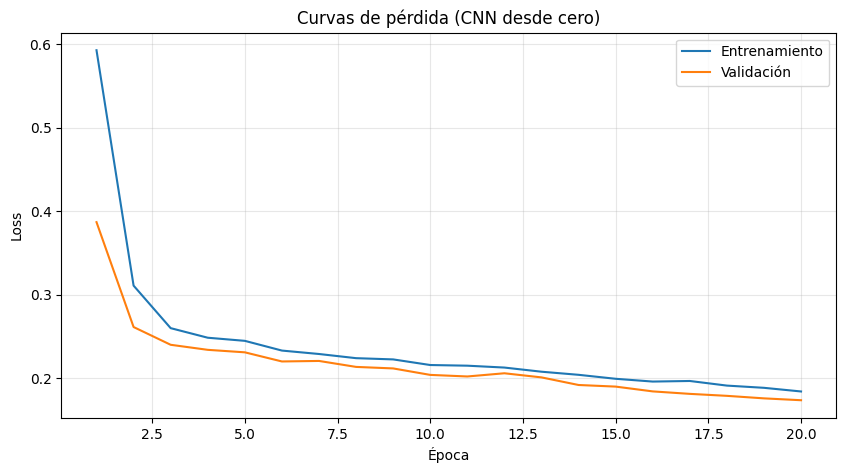

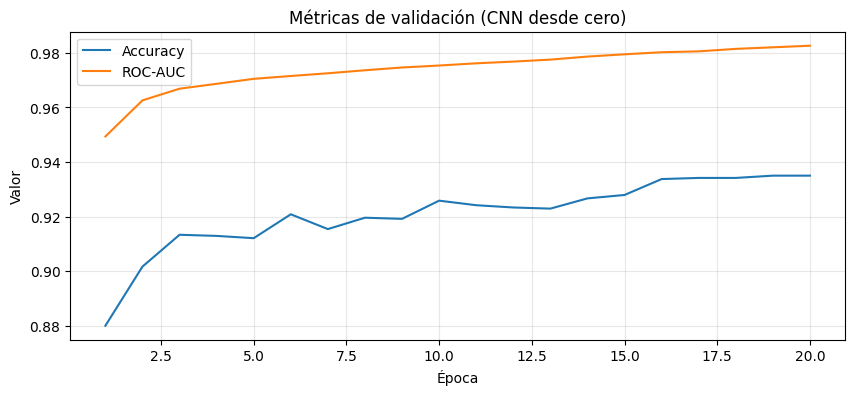

In [11]:
epochs_range = range(
    1,
    len(
        history_scratch[
            "train_loss"
        ]
    ) + 1
)

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    epochs_range,
    history_scratch[
        "train_loss"
    ],
    label="Entrenamiento"
)

plt.plot(
    epochs_range,
    history_scratch[
        "val_loss"
    ],
    label="Validación"
)

plt.title(
    "Curvas de pérdida (CNN desde cero)"
)

plt.xlabel("Época")
plt.ylabel("Loss")

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()


plt.figure(
    figsize=(10, 4)
)

plt.plot(
    epochs_range,
    history_scratch[
        "val_acc"
    ],
    label="Accuracy"
)

plt.plot(
    epochs_range,
    history_scratch[
        "val_auc"
    ],
    label="ROC-AUC"
)

plt.title(
    "Métricas de validación (CNN desde cero)"
)

plt.xlabel("Época")
plt.ylabel("Valor")

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()

### 5.4. CNN con Dropout

In [12]:
class CNNDropout(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                in_channels=1,
                out_channels=16,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                in_channels=16,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Dropout más suave
            nn.Dropout2d(
                p=0.10
            ),

            nn.AdaptiveAvgPool2d(
                (1, 1)
            )
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Dropout(
                p=0.20
            ),

            nn.Linear(
                32,
                num_classes
            )
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)

        return x


model_dropout = CNNDropout(
    num_classes=num_classes
).to(device)

In [13]:
criterion_dropout = nn.CrossEntropyLoss()

optimizer_dropout = torch.optim.Adam(
    model_dropout.parameters(),
    lr=1e-3
)

epochs_dropout = 20

history_dropout = {
    "train_loss": [],
    "val_loss": [],
    "val_acc": [],
    "val_auc": []
}

for epoch in range(
    1,
    epochs_dropout + 1
):

    train_loss = train_one_epoch(
        model_dropout,
        train_loader,
        optimizer_dropout,
        criterion_dropout
    )

    val_loss = evaluate_loss(
        model_dropout,
        val_loader,
        criterion_dropout
    )

    (
        val_acc,
        val_auc,
        _,
        _,
        _
    ) = evaluate(
        model_dropout,
        val_loader
    )

    history_dropout["train_loss"].append(
        train_loss
    )

    history_dropout["val_loss"].append(
        val_loss
    )

    history_dropout["val_acc"].append(
        val_acc
    )

    history_dropout["val_auc"].append(
        val_auc
    )

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"val_auc={val_auc:.4f}"
    )

Epoch 01 | train_loss=0.5576 | val_loss=0.3955 | val_acc=0.8754 | val_auc=0.9396
Epoch 02 | train_loss=0.3850 | val_loss=0.3065 | val_acc=0.8904 | val_auc=0.9541
Epoch 03 | train_loss=0.3463 | val_loss=0.2809 | val_acc=0.8992 | val_auc=0.9598
Epoch 04 | train_loss=0.3234 | val_loss=0.2679 | val_acc=0.9058 | val_auc=0.9623
Epoch 05 | train_loss=0.3154 | val_loss=0.2581 | val_acc=0.9092 | val_auc=0.9646
Epoch 06 | train_loss=0.2988 | val_loss=0.2486 | val_acc=0.9042 | val_auc=0.9671
Epoch 07 | train_loss=0.2854 | val_loss=0.2403 | val_acc=0.9133 | val_auc=0.9692
Epoch 08 | train_loss=0.2754 | val_loss=0.2335 | val_acc=0.9163 | val_auc=0.9708
Epoch 09 | train_loss=0.2639 | val_loss=0.2221 | val_acc=0.9179 | val_auc=0.9728
Epoch 10 | train_loss=0.2540 | val_loss=0.2205 | val_acc=0.9163 | val_auc=0.9751
Epoch 11 | train_loss=0.2462 | val_loss=0.2124 | val_acc=0.9221 | val_auc=0.9757
Epoch 12 | train_loss=0.2383 | val_loss=0.2032 | val_acc=0.9246 | val_auc=0.9773
Epoch 13 | train_loss=0.2339

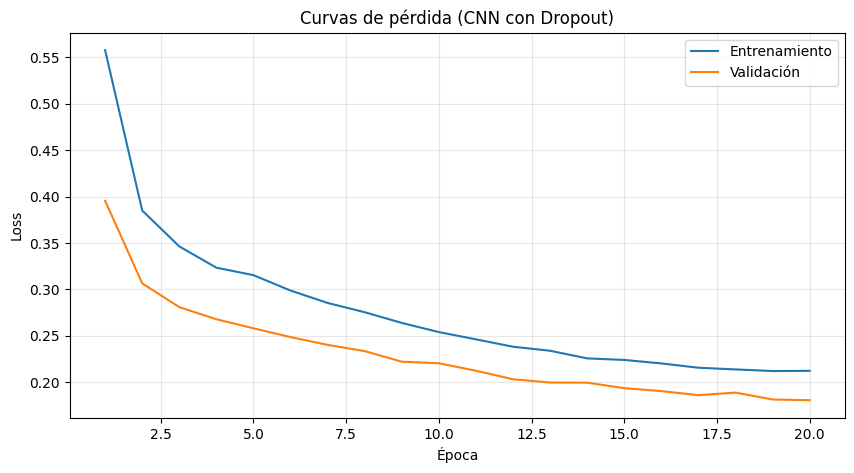

In [14]:
epochs_dropout_range = range(
    1,
    len(history_dropout["train_loss"]) + 1
)

plt.figure(figsize=(10, 5))

plt.plot(
    epochs_dropout_range,
    history_dropout["train_loss"],
    label="Entrenamiento"
)

plt.plot(
    epochs_dropout_range,
    history_dropout["val_loss"],
    label="Validación"
)

plt.title(
    "Curvas de pérdida (CNN con Dropout)"
)

plt.xlabel("Época")
plt.ylabel("Loss")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

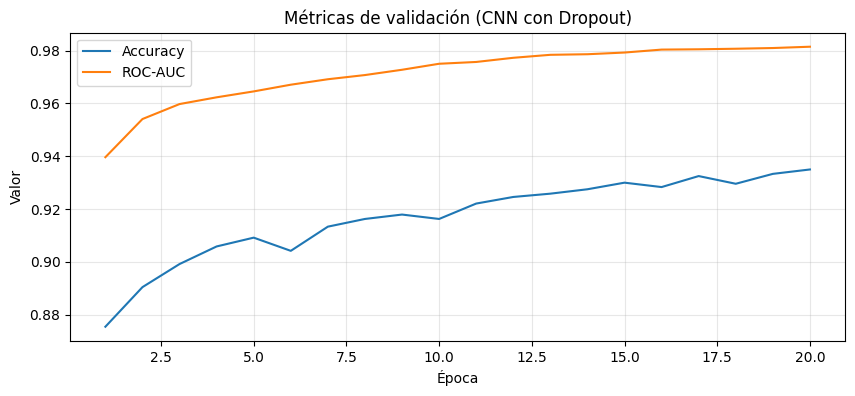

In [15]:
plt.figure(figsize=(10, 4))

plt.plot(
    epochs_dropout_range,
    history_dropout["val_acc"],
    label="Accuracy"
)

plt.plot(
    epochs_dropout_range,
    history_dropout["val_auc"],
    label="ROC-AUC"
)

plt.title(
    "Métricas de validación (CNN con Dropout)"
)

plt.xlabel("Época")
plt.ylabel("Valor")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [16]:
print("CNN original")
print(
    "Accuracy:",
    history_scratch["val_acc"][-1]
)
print(
    "ROC-AUC:",
    history_scratch["val_auc"][-1]
)

print()

print("CNN con Dropout")
print(
    "Accuracy:",
    history_dropout["val_acc"][-1]
)
print(
    "ROC-AUC:",
    history_dropout["val_auc"][-1]
)

CNN original
Accuracy: 0.935
ROC-AUC: 0.9826173611111111

CNN con Dropout
Accuracy: 0.935
ROC-AUC: 0.981511111111111


### Comparación entre la CNN original y la CNN con Dropout

La CNN original obtuvo un **Accuracy de 0.935** y un **ROC-AUC de 0.9826**.

Por otro lado, la CNN con Dropout obtuvo el mismo **Accuracy de 0.935**, pero un ROC-AUC ligeramente menor de **0.9815**.

Por lo tanto, en esta ejecución el uso de Dropout no produjo una mejora en el rendimiento del modelo. Ambos modelos presentan un desempeño muy similar, aunque la CNN original obtuvo un ROC-AUC ligeramente superior.

Esto indica que, para esta configuración, el Dropout no aportó una mejora significativa en la capacidad de clasificación.

### 5.6. Experimento con Learning Rate y Scheduler

En esta sección se evaluará cómo influye el **learning rate** en el entrenamiento de la CNN con Dropout.

El **learning rate** determina el tamaño de los ajustes que realiza el optimizador sobre los pesos de la red. Un valor demasiado alto puede generar inestabilidad durante el entrenamiento, mientras que un valor demasiado bajo puede hacer que el aprendizaje sea más lento.

También se utilizará un **scheduler**, cuya función es modificar automáticamente el learning rate conforme avanzan las épocas. Esto permite comenzar con ajustes relativamente grandes y reducirlos progresivamente para realizar cambios más pequeños al final del entrenamiento.

Se compararán las siguientes configuraciones:

- **Learning rate = 0.001**
- **Learning rate = 0.0005**
- **Learning rate = 0.001 + StepLR**

Para el experimento con `StepLR`, el learning rate se reducirá cada 3 épocas utilizando un factor de 0.5.

El objetivo es comparar el comportamiento de cada configuración mediante:

- Pérdida de entrenamiento.
- Pérdida de validación.
- Accuracy de validación.
- ROC-AUC.

De esta manera se podrá identificar qué configuración permite obtener un entrenamiento más estable y un mejor rendimiento del modelo.

# Función para los experimentos

In [17]:
def train_lr_experiment(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    epochs,
    scheduler=None
):
    history = {
        "train_loss": [],
        "val_loss": [],
        "val_acc": [],
        "val_auc": [],
        "lr": []
    }

    for epoch in range(1, epochs + 1):

        # Entrenamiento
        train_loss = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion
        )

        # Pérdida de validación
        val_loss = evaluate_loss(
            model,
            val_loader,
            criterion
        )

        # Métricas de validación
        (
            val_acc,
            val_auc,
            _,
            _,
            _
        ) = evaluate(
            model,
            val_loader
        )

        # Learning rate actual
        current_lr = optimizer.param_groups[0]["lr"]

        # Guardar resultados
        history["train_loss"].append(
            train_loss
        )

        history["val_loss"].append(
            val_loss
        )

        history["val_acc"].append(
            val_acc
        )

        history["val_auc"].append(
            val_auc
        )

        history["lr"].append(
            current_lr
        )

        print(
            f"Epoch {epoch:02d} | "
            f"LR={current_lr:.6f} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"val_acc={val_acc:.4f} | "
            f"val_auc={val_auc:.4f}"
        )

        # Actualizar learning rate
        if scheduler is not None:
            scheduler.step()

    return history

# Configuraciones

In [18]:
experiments = {
    "LR = 0.001": {
        "lr": 1e-3,
        "scheduler": False
    },

    "LR = 0.0005": {
        "lr": 5e-4,
        "scheduler": False
    },

    "LR = 0.001 + StepLR": {
        "lr": 1e-3,
        "scheduler": True
    }
}

experiment_epochs = 10

criterion_exp = nn.CrossEntropyLoss()

experiment_results = {}
experiment_models = {}

# Ejecutar los experimentos

In [19]:
for name, config in experiments.items():

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    # Misma semilla para comparar
    # los experimentos de forma más justa
    torch.manual_seed(42)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(42)

    # Crear una CNN con Dropout nueva
    model_exp = CNNDropout(
        num_classes=num_classes
    ).to(device)

    # Optimizador
    optimizer_exp = torch.optim.Adam(
        model_exp.parameters(),
        lr=config["lr"]
    )

    scheduler_exp = None

    # Scheduler solo para el tercer experimento
    if config["scheduler"]:

        scheduler_exp = torch.optim.lr_scheduler.StepLR(
            optimizer_exp,
            step_size=3,
            gamma=0.5
        )

    # Entrenar
    history_exp = train_lr_experiment(
        model=model_exp,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer_exp,
        criterion=criterion_exp,
        epochs=experiment_epochs,
        scheduler=scheduler_exp
    )

    # Guardar resultados
    experiment_results[name] = history_exp
    experiment_models[name] = model_exp


LR = 0.001
Epoch 01 | LR=0.001000 | train_loss=0.6036 | val_loss=0.4452 | val_acc=0.8679 | val_auc=0.9457
Epoch 02 | LR=0.001000 | train_loss=0.3942 | val_loss=0.3060 | val_acc=0.8950 | val_auc=0.9573
Epoch 03 | LR=0.001000 | train_loss=0.3370 | val_loss=0.2724 | val_acc=0.9054 | val_auc=0.9636
Epoch 04 | LR=0.001000 | train_loss=0.3118 | val_loss=0.2577 | val_acc=0.9075 | val_auc=0.9675
Epoch 05 | LR=0.001000 | train_loss=0.2935 | val_loss=0.2430 | val_acc=0.9150 | val_auc=0.9699
Epoch 06 | LR=0.001000 | train_loss=0.2857 | val_loss=0.2346 | val_acc=0.9200 | val_auc=0.9718
Epoch 07 | LR=0.001000 | train_loss=0.2702 | val_loss=0.2268 | val_acc=0.9213 | val_auc=0.9732
Epoch 08 | LR=0.001000 | train_loss=0.2610 | val_loss=0.2265 | val_acc=0.9179 | val_auc=0.9740
Epoch 09 | LR=0.001000 | train_loss=0.2502 | val_loss=0.2150 | val_acc=0.9221 | val_auc=0.9756
Epoch 10 | LR=0.001000 | train_loss=0.2433 | val_loss=0.2236 | val_acc=0.9125 | val_auc=0.9774

LR = 0.0005
Epoch 01 | LR=0.000500 | 

# Comparar pérdida de validación

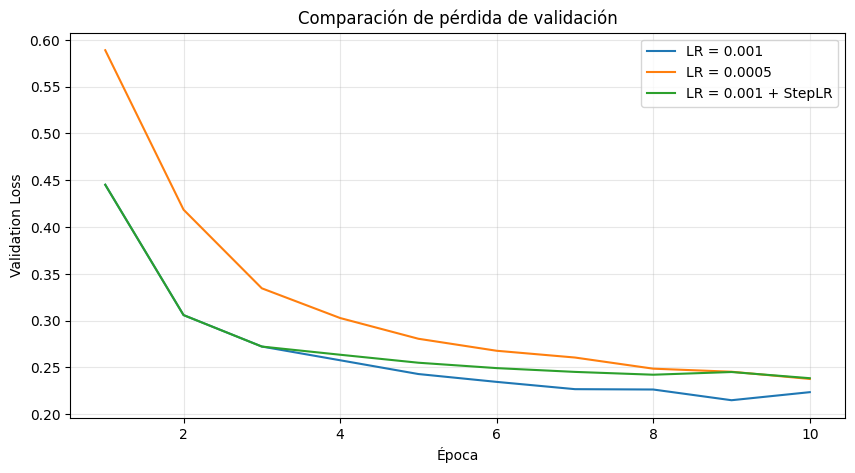

In [20]:
plt.figure(figsize=(10, 5))

for name, history in experiment_results.items():

    epochs_exp = range(
        1,
        len(history["val_loss"]) + 1
    )

    plt.plot(
        epochs_exp,
        history["val_loss"],
        label=name
    )

plt.title(
    "Comparación de pérdida de validación"
)

plt.xlabel("Época")
plt.ylabel("Validation Loss")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

# Comparar Accuracy

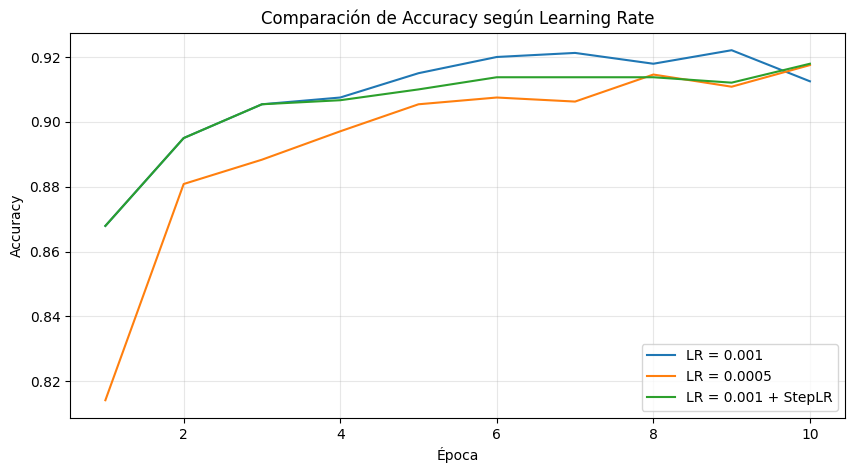

In [21]:
plt.figure(figsize=(10, 5))

for name, history in experiment_results.items():

    epochs_exp = range(
        1,
        len(history["val_acc"]) + 1
    )

    plt.plot(
        epochs_exp,
        history["val_acc"],
        label=name
    )

plt.title(
    "Comparación de Accuracy según Learning Rate"
)

plt.xlabel("Época")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

# Comparar ROC-AUC

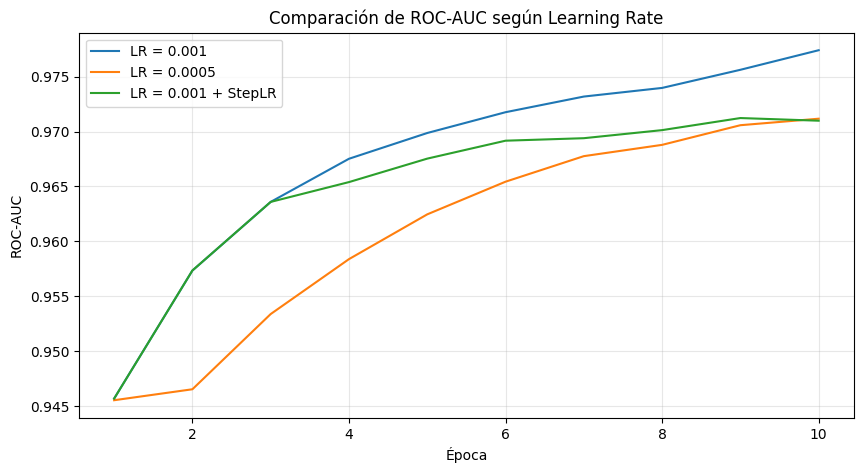

In [22]:
plt.figure(figsize=(10, 5))

for name, history in experiment_results.items():

    epochs_exp = range(
        1,
        len(history["val_auc"]) + 1
    )

    plt.plot(
        epochs_exp,
        history["val_auc"],
        label=name
    )

plt.title(
    "Comparación de ROC-AUC según Learning Rate"
)

plt.xlabel("Época")
plt.ylabel("ROC-AUC")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

# Mostrar cómo cambia el Scheduler

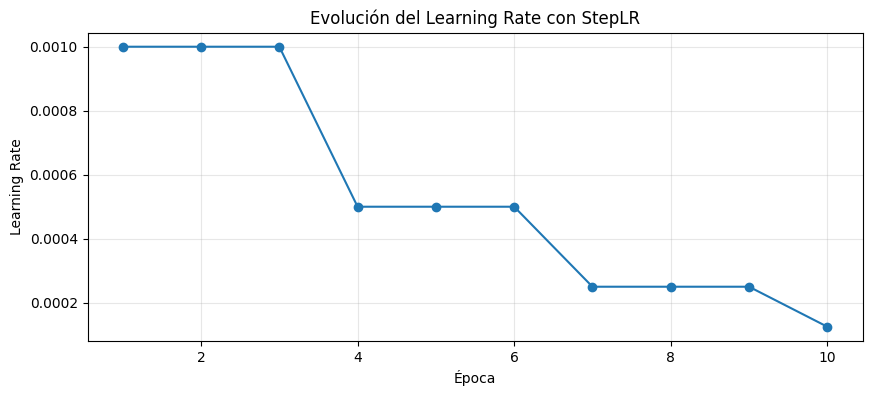

In [23]:
history_scheduler = experiment_results[
    "LR = 0.001 + StepLR"
]

epochs_scheduler = range(
    1,
    len(history_scheduler["lr"]) + 1
)

plt.figure(figsize=(10, 4))

plt.plot(
    epochs_scheduler,
    history_scheduler["lr"],
    marker="o"
)

plt.title(
    "Evolución del Learning Rate con StepLR"
)

plt.xlabel("Época")
plt.ylabel("Learning Rate")

plt.grid(alpha=0.3)

plt.show()

# Resultados Finales

In [24]:
print("Resultados finales")
print("=" * 50)

for name, history in experiment_results.items():

    print(f"\n{name}")

    print(
        f"Validation Loss: "
        f"{history['val_loss'][-1]:.4f}"
    )

    print(
        f"Accuracy: "
        f"{history['val_acc'][-1]:.4f}"
    )

    print(
        f"ROC-AUC: "
        f"{history['val_auc'][-1]:.4f}"
    )

Resultados finales

LR = 0.001
Validation Loss: 0.2236
Accuracy: 0.9125
ROC-AUC: 0.9774

LR = 0.0005
Validation Loss: 0.2378
Accuracy: 0.9175
ROC-AUC: 0.9712

LR = 0.001 + StepLR
Validation Loss: 0.2386
Accuracy: 0.9179
ROC-AUC: 0.9710


### Análisis del Learning Rate y Scheduler

Se compararon tres configuraciones de entrenamiento:

- **LR = 0.001**
  - Validation Loss: `0.2236`
  - Accuracy: `0.9125`
  - ROC-AUC: `0.9774`

- **LR = 0.0005**
  - Validation Loss: `0.2378`
  - Accuracy: `0.9175`
  - ROC-AUC: `0.9712`

- **LR = 0.001 + StepLR**
  - Validation Loss: `0.2386`
  - Accuracy: `0.9179`
  - ROC-AUC: `0.9710`

La configuración con **LR = 0.001** presentó la menor pérdida de validación y el mayor ROC-AUC.

Aunque la configuración con StepLR obtuvo un Accuracy ligeramente superior, su pérdida de validación fue mayor y su ROC-AUC fue menor.

Por lo tanto, se selecciona **LR = 0.001** como la mejor configuración general, ya que presentó un mejor equilibrio entre pérdida de validación, Accuracy y capacidad de separación entre las clases.

### 5.4. Evaluación final en test

La evaluación final se realiza sobre un conjunto no utilizado durante el entrenamiento.

In [25]:
(
    test_acc,
    test_auc,
    y_true,
    y_pred,
    y_prob
) = evaluate(
    model_scratch,
    test_loader
)

print(
    f"Test accuracy: {test_acc:.4f}"
)

print(
    f"Test ROC-AUC:  {test_auc:.4f}"
)

print()

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

Test accuracy: 0.9335
Test ROC-AUC:  0.9832

              precision    recall  f1-score   support

     Sneaker     0.9263    0.9420    0.9341      1000
  Ankle boot     0.9410    0.9250    0.9329      1000

    accuracy                         0.9335      2000
   macro avg     0.9336    0.9335    0.9335      2000
weighted avg     0.9336    0.9335    0.9335      2000



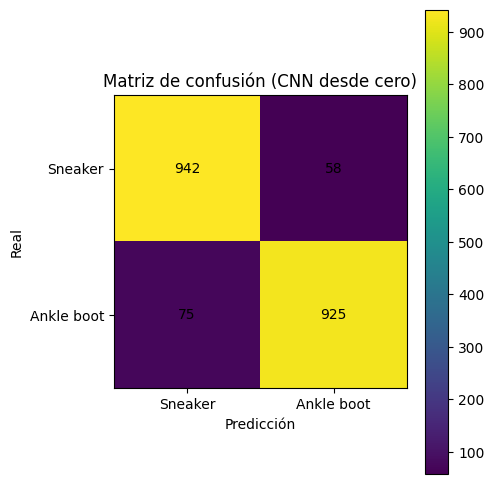

In [26]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(
    figsize=(5, 5)
)

plt.imshow(cm)

plt.title(
    "Matriz de confusión (CNN desde cero)"
)

plt.xlabel("Predicción")
plt.ylabel("Real")

plt.xticks(
    [0, 1],
    class_names
)

plt.yticks(
    [0, 1],
    class_names
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

## 6. Data Augmentation (aumento de datos)

El Data Augmentation permite generar variaciones de las imágenes durante el entrenamiento con el objetivo de mejorar la capacidad de generalización del modelo.

Para mantener las características principales de las imágenes se utilizarán aumentos moderados:

- Rotaciones pequeñas de hasta 10°.
- Traslaciones horizontales y verticales de hasta 5 %.

Luego se entrenará una CNN con el mismo diseño utilizado anteriormente para comparar el rendimiento del modelo con y sin Data Augmentation.

In [30]:
transform_aug = T.Compose([
    T.RandomRotation(degrees=10),
    T.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05)
    ),
    T.ToTensor()
])

In [31]:
train_dataset_aug_full = BinaryFashionMNIST(
    root="./data",
    train=True,
    transform=transform_aug,
    download=True
)

train_dataset_aug = Subset(
    train_dataset_aug_full,
    train_idx
)

train_loader_aug = DataLoader(
    train_dataset_aug,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

In [32]:
model_aug = SimpleCNN(
    num_classes=num_classes
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model_aug.parameters(),
    lr=1e-3
)

epochs = 6

history_aug = {
    "train_loss": [],
    "val_acc": [],
    "val_auc": []
}

In [33]:
for epoch in range(1, epochs + 1):

    train_loss = train_one_epoch(
        model_aug,
        train_loader_aug,
        optimizer,
        criterion
    )

    val_acc, val_auc, _, _, _ = evaluate(
        model_aug,
        val_loader
    )

    history_aug["train_loss"].append(
        train_loss
    )

    history_aug["val_acc"].append(
        val_acc
    )

    history_aug["val_auc"].append(
        val_auc
    )

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"val_auc={val_auc:.4f}"
    )

Epoch 01 | train_loss=0.5855 | val_acc=0.8729 | val_auc=0.9380
Epoch 02 | train_loss=0.3395 | val_acc=0.8942 | val_auc=0.9548
Epoch 03 | train_loss=0.2911 | val_acc=0.8988 | val_auc=0.9619
Epoch 04 | train_loss=0.2721 | val_acc=0.9046 | val_auc=0.9650
Epoch 05 | train_loss=0.2617 | val_acc=0.9096 | val_auc=0.9675
Epoch 06 | train_loss=0.2516 | val_acc=0.9050 | val_auc=0.9706


### 6.1. Comparación rápida

Finalmente se comparará el rendimiento de la CNN entrenada sin Data Augmentation con la CNN entrenada utilizando rotaciones y traslaciones.

La comparación se realizará sobre el conjunto de prueba utilizando Accuracy y ROC-AUC.

In [34]:
test_acc_base, test_auc_base, _, _, _ = evaluate(
    model_scratch,
    test_loader
)

test_acc_aug, test_auc_aug, _, _, _ = evaluate(
    model_aug,
    test_loader
)

print(
    f"Sin augmentation  | "
    f"test_acc={test_acc_base:.4f} | "
    f"test_auc={test_auc_base:.4f}"
)

print(
    f"Con augmentation  | "
    f"test_acc={test_acc_aug:.4f} | "
    f"test_auc={test_auc_aug:.4f}"
)

Sin augmentation  | test_acc=0.9335 | test_auc=0.9832
Con augmentation  | test_acc=0.9015 | test_auc=0.9703


### 6.2. Análisis del Data Augmentation

Se comparó el rendimiento de la CNN entrenada con las imágenes originales frente a la misma arquitectura entrenada utilizando Data Augmentation.

El modelo **sin Data Augmentation** obtuvo un Accuracy de `0.9335` y un ROC-AUC de `0.9832`.

Por otro lado, el modelo **con Data Augmentation** obtuvo un Accuracy de `0.9015` y un ROC-AUC de `0.9703`.

En esta ejecución, el uso de pequeñas rotaciones y traslaciones no mejoró el rendimiento del modelo. Por el contrario, se observó una disminución tanto en Accuracy como en ROC-AUC.

Por lo tanto, para las siguientes etapas se continuará utilizando el modelo entrenado **sin Data Augmentation**, ya que presentó el mejor desempeño sobre el conjunto de prueba.

## 7. Calibración de probabilidades y análisis de curva ROC

Después de comparar la CNN entrenada con y sin Data Augmentation, se seleccionó el modelo **sin Data Augmentation**, ya que presentó el mejor rendimiento.

Para analizar las probabilidades generadas por el modelo, los logits serán transformados en probabilidades mediante **Softmax**.

Posteriormente, se utilizará un umbral de `0.5` para convertir estas probabilidades en predicciones de clase.

A partir de estos resultados se analizarán:

- Accuracy.
- ROC-AUC.
- Matriz de confusión.
- Precision, Recall y F1-score.
- Curva ROC.

Las clases utilizadas son:

- Clase `0`: Sneaker.
- Clase `1`: Ankle boot.

## 7.1. Importar métricas


In [36]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

import numpy as np
import matplotlib.pyplot as plt

## 7.2. Convertir logits a probabilidades

La salida directa de la red neuronal corresponde a valores llamados **logits**.

Para poder interpretarlos como probabilidades se utiliza:

- `Sigmoid` si el modelo posee una sola salida.
- `Softmax` si el modelo posee dos salidas.

Como la CNN utilizada tiene dos salidas, se aplicará Softmax y se tomará la probabilidad correspondiente a la clase positiva, **Ankle boot**.

In [37]:
def logits_to_probs(logits):

    if logits.shape[1] == 1:

        return torch.sigmoid(
            logits
        ).squeeze(1)

    return torch.softmax(
        logits,
        dim=1
    )[:, 1]

### 7.3. Evaluación utilizando probabilidades

Una vez obtenidas las probabilidades, se utilizará un umbral de `0.5` para determinar la clase predicha.

- Probabilidad menor a `0.5`: Sneaker.
- Probabilidad mayor o igual a `0.5`: Ankle boot.

Además, las probabilidades serán almacenadas para calcular el ROC-AUC y construir posteriormente la curva ROC.

In [38]:
@torch.no_grad()
def evaluate_probs(model, loader):

    model.eval()

    all_labels = []
    all_probs = []
    all_preds = []

    for x, y in loader:

        x = x.to(device)

        # Adaptado a FashionMNIST
        y = y.to(device).long().view(-1)

        # Obtener logits
        logits = model(x)

        # Convertir logits a probabilidades
        probs = logits_to_probs(
            logits
        )

        # Aplicar umbral de 0.5
        preds = (
            probs >= 0.5
        ).long()

        all_labels.append(
            y.cpu().numpy()
        )

        all_probs.append(
            probs.cpu().numpy()
        )

        all_preds.append(
            preds.cpu().numpy()
        )

    y_true = np.concatenate(
        all_labels
    )

    y_prob = np.concatenate(
        all_probs
    )

    y_pred = np.concatenate(
        all_preds
    )

    acc = accuracy_score(
        y_true,
        y_pred
    )

    auc = roc_auc_score(
        y_true,
        y_prob
    )

    return (
        acc,
        auc,
        y_true,
        y_pred,
        y_prob
    )

### 7.4. Selección del modelo

La CNN entrenada sin Data Augmentation obtuvo mejores resultados que el modelo entrenado con aumento de datos.

Por esta razón, se utilizará la CNN sin Data Augmentation para realizar el análisis de probabilidades y de la curva ROC.

In [39]:
best_model = model_scratch

## 7.5. Evaluar el modelo

In [40]:
(
    test_acc,
    test_auc,
    y_true,
    y_pred,
    y_prob
) = evaluate_probs(
    best_model,
    test_loader
)

print(
    f"Test Accuracy: {test_acc:.4f}"
)

print(
    f"Test ROC-AUC: {test_auc:.4f}"
)

Test Accuracy: 0.9335
Test ROC-AUC: 0.9832


### 7.6. Matriz de confusión

La matriz de confusión permite observar las predicciones correctas e incorrectas realizadas por el modelo.

Las filas representan las clases reales y las columnas representan las clases predichas.

Los valores ubicados en la diagonal principal representan las clasificaciones correctas, mientras que los valores fuera de la diagonal corresponden a errores de clasificación.

In [41]:
class_names = [
    "Sneaker",
    "Ankle boot"
]

cm = confusion_matrix(
    y_true,
    y_pred
)

print(cm)

[[942  58]
 [ 75 925]]


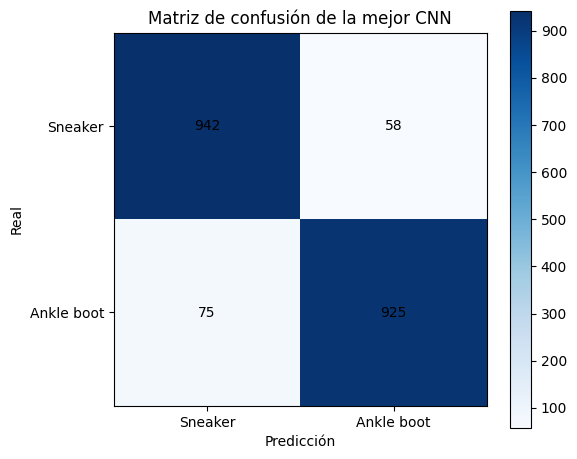

In [42]:
plt.figure(
    figsize=(6, 5)
)

plt.imshow(
    cm,
    cmap="Blues"
)

plt.title(
    "Matriz de confusión de la mejor CNN"
)

plt.xlabel(
    "Predicción"
)

plt.ylabel(
    "Real"
)

plt.xticks(
    [0, 1],
    class_names
)

plt.yticks(
    [0, 1],
    class_names
)

for i in range(2):

    for j in range(2):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.tight_layout()

plt.show()

### 7.7. Classification Report

Además del Accuracy, se utilizarán las métricas Precision, Recall y F1-score para analizar el comportamiento del modelo en cada una de las clases.

In [43]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

              precision    recall  f1-score   support

     Sneaker     0.9263    0.9420    0.9341      1000
  Ankle boot     0.9410    0.9250    0.9329      1000

    accuracy                         0.9335      2000
   macro avg     0.9336    0.9335    0.9335      2000
weighted avg     0.9336    0.9335    0.9335      2000



### 7.8. Curva ROC

La curva ROC permite analizar la capacidad del modelo para diferenciar las dos clases utilizando distintos umbrales de clasificación.

En esta gráfica:

- El eje X representa la tasa de falsos positivos (`False Positive Rate`).
- El eje Y representa la tasa de verdaderos positivos (`True Positive Rate`).

Una curva cercana a la esquina superior izquierda representa un mejor comportamiento.

El valor ROC-AUC resume el desempeño de la curva. Un valor cercano a `1` indica una buena capacidad para diferenciar entre las clases.

In [44]:
fpr, tpr, thresholds = roc_curve(
    y_true,
    y_prob
)

auc = roc_auc_score(
    y_true,
    y_prob
)

print(
    f"ROC-AUC: {auc:.4f}"
)

ROC-AUC: 0.9832


### 7.9. Graficar la curva ROC

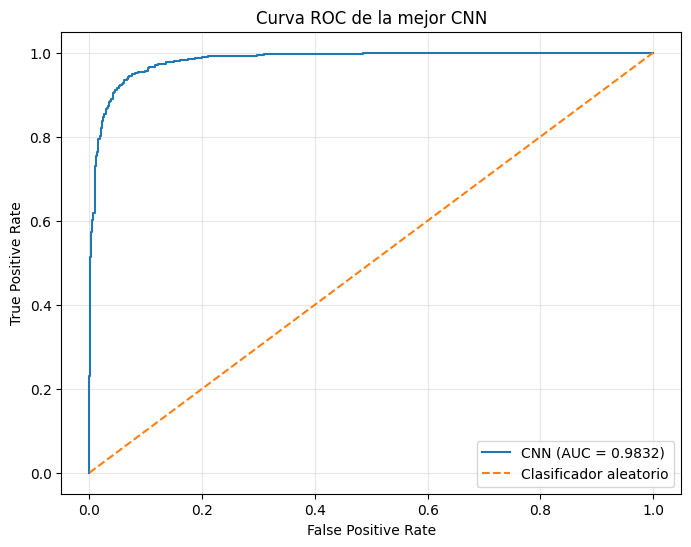

In [45]:
plt.figure(
    figsize=(8, 6)
)

plt.plot(
    fpr,
    tpr,
    label=f"CNN (AUC = {auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Clasificador aleatorio"
)

plt.title(
    "Curva ROC de la mejor CNN"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()

### Análisis de la curva ROC

La curva ROC obtenida se encuentra muy por encima de la línea diagonal correspondiente a un clasificador aleatorio y se aproxima a la esquina superior izquierda de la gráfica.

El modelo obtuvo un **ROC-AUC de 0.9832**, un valor muy cercano a `1`. Esto indica que la CNN presenta una **muy buena capacidad para diferenciar entre las clases Sneaker y Ankle boot**.

Además, la forma de la curva muestra que el modelo puede alcanzar una alta tasa de verdaderos positivos manteniendo una tasa relativamente baja de falsos positivos para distintos umbrales de clasificación.

Por lo tanto, el resultado de la curva ROC indica que el modelo tiene un buen poder de discriminación entre ambas clases.

## 8. Transfer Learning

El Transfer Learning consiste en reutilizar un modelo previamente entrenado en un conjunto de datos grande y adaptarlo a una nueva tarea de clasificación.

En este caso se utilizará **ResNet18**, un modelo preentrenado en ImageNet, para clasificar las imágenes de FashionMNIST correspondientes a las clases **Sneaker** y **Ankle boot**.

Para utilizar ResNet18 será necesario:

1. Redimensionar las imágenes a `224 × 224`.
2. Convertir las imágenes de 1 canal a 3 canales.
3. Reemplazar la capa final para trabajar con las dos clases del problema.
4. Entrenar inicialmente solo la última capa.
5. Realizar posteriormente Fine-tuning sobre las últimas capas del modelo.

### 8.1. Preparar los datos para ResNet18

ResNet18 fue diseñada para trabajar con imágenes de tres canales. Por esta razón, las imágenes de FashionMNIST serán redimensionadas a `224 × 224` y convertidas de un canal a tres canales.

Para el conjunto de entrenamiento también se aplicarán pequeñas rotaciones y traslaciones.

In [47]:
import torch
import torch.nn as nn

from torch.utils.data import (
    DataLoader,
    Subset
)

from torchvision import transforms as T
import torchvision.models as models

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

import numpy as np
import matplotlib.pyplot as plt

## Crear los datasets para Transfer Learning

In [52]:
train_dataset_tl_full = BinaryFashionMNIST(
    root="./data",
    train=True,
    transform=transform_tl_train,
    download=True
)

val_dataset_tl_full = BinaryFashionMNIST(
    root="./data",
    train=True,
    transform=transform_tl_eval,
    download=True
)

test_dataset_tl = BinaryFashionMNIST(
    root="./data",
    train=False,
    transform=transform_tl_eval,
    download=True
)

## Crear train_dataset_tl y val_dataset_tl

In [53]:
train_dataset_tl = Subset(
    train_dataset_tl_full,
    train_idx
)

val_dataset_tl = Subset(
    val_dataset_tl_full,
    val_idx
)

In [54]:
print("Train:", len(train_dataset_tl))
print("Validation:", len(val_dataset_tl))
print("Test:", len(test_dataset_tl))

Train: 9600
Validation: 2400
Test: 2000


## Crear los DataLoaders

In [55]:
train_loader_tl = DataLoader(
    train_dataset_tl,
    batch_size=64,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader_tl = DataLoader(
    val_dataset_tl,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

test_loader_tl = DataLoader(
    test_dataset_tl,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

## Comprobar que ResNet recibirá el tamaño correcto

In [56]:
images, labels = next(
    iter(train_loader_tl)
)

print("Imágenes:", images.shape)
print("Etiquetas:", labels.shape)

Imágenes: torch.Size([64, 3, 224, 224])
Etiquetas: torch.Size([64])


### 8.2. Construir el modelo preentrenado

Se utilizará **ResNet18** preentrenada en ImageNet.

La estrategia será:

- Congelar inicialmente las capas preentrenadas.
- Reemplazar la última capa para trabajar con dos clases.
- Entrenar solamente la última capa.
- Posteriormente realizar Fine-tuning sobre las últimas capas del modelo.

In [57]:
import torchvision.models as models

num_classes = 2

resnet = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

in_features = resnet.fc.in_features

resnet.fc = nn.Linear(
    in_features,
    num_classes
)

resnet = resnet.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 129MB/s]


In [58]:
for name, param in resnet.named_parameters():
    param.requires_grad = False

In [59]:
for param in resnet.fc.parameters():
    param.requires_grad = True

In [60]:
resnet

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### 8.3. Entrenamiento de la capa final

En esta primera etapa se mantienen congeladas las capas preentrenadas de ResNet18.

Únicamente se entrenará la capa final (`fc`) para adaptar el modelo a las clases **Sneaker** y **Ankle boot**.

In [63]:
def train_one_epoch_tl(
    model,
    loader,
    optimizer,
    criterion
):
    model.train()

    losses = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().view(-1)

        optimizer.zero_grad()

        logits = model(x)

        loss = criterion(
            logits,
            y
        )

        loss.backward()
        optimizer.step()

        losses.append(
            loss.item()
        )

    return float(
        np.mean(losses)
    )


@torch.no_grad()
def evaluate_tl(
    model,
    loader
):
    model.eval()

    all_labels = []
    all_probs = []
    all_preds = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().view(-1)

        logits = model(x)

        probs = torch.softmax(
            logits,
            dim=1
        )[:, 1]

        preds = (
            probs >= 0.5
        ).long()

        all_labels.append(
            y.cpu().numpy()
        )

        all_probs.append(
            probs.cpu().numpy()
        )

        all_preds.append(
            preds.cpu().numpy()
        )

    y_true = np.concatenate(
        all_labels
    )

    y_prob = np.concatenate(
        all_probs
    )

    y_pred = np.concatenate(
        all_preds
    )

    acc = accuracy_score(
        y_true,
        y_pred
    )

    auc = roc_auc_score(
        y_true,
        y_prob
    )

    return (
        acc,
        auc,
        y_true,
        y_pred,
        y_prob
    )

In [64]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    resnet.fc.parameters(),
    lr=1e-3
)

epochs = 4

history_tl_stage1 = {
    "train_loss": [],
    "val_acc": [],
    "val_auc": []
}

In [65]:
for epoch in range(1, epochs + 1):

    train_loss = train_one_epoch_tl(
        resnet,
        train_loader_tl,
        optimizer,
        criterion
    )

    val_acc, val_auc, _, _, _ = evaluate_tl(
        resnet,
        val_loader_tl
    )

    history_tl_stage1["train_loss"].append(
        train_loss
    )

    history_tl_stage1["val_acc"].append(
        val_acc
    )

    history_tl_stage1["val_auc"].append(
        val_auc
    )

    print(
        f"Stage1 Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"val_auc={val_auc:.4f}"
    )

Stage1 Epoch 01 | train_loss=0.2455 | val_acc=0.9375 | val_auc=0.9849
Stage1 Epoch 02 | train_loss=0.1718 | val_acc=0.9433 | val_auc=0.9878
Stage1 Epoch 03 | train_loss=0.1622 | val_acc=0.9300 | val_auc=0.9889
Stage1 Epoch 04 | train_loss=0.1686 | val_acc=0.9529 | val_auc=0.9894


### 8.4. Fine-tuning

Después de entrenar únicamente la capa final de ResNet18, se realizará Fine-tuning.

Para ello se descongelarán las últimas capas del modelo, específicamente `layer4` y `fc`, permitiendo que estas capas se ajusten mejor a las características de las imágenes de FashionMNIST.

En esta etapa se utilizará un learning rate menor para realizar modificaciones más pequeñas sobre los pesos preentrenados.

In [66]:
for name, param in resnet.named_parameters():

    if name.startswith("layer4") or name.startswith("fc"):

        param.requires_grad = True


In [67]:
trainable_params = [
    p
    for p in resnet.parameters()
    if p.requires_grad
]

len(trainable_params)

17

In [68]:
optimizer = torch.optim.Adam(
    trainable_params,
    lr=1e-4
)

epochs = 4

history_tl_stage2 = {
    "train_loss": [],
    "val_acc": [],
    "val_auc": []
}

In [69]:
for epoch in range(1, epochs + 1):

    train_loss = train_one_epoch_tl(
        resnet,
        train_loader_tl,
        optimizer,
        criterion
    )

    val_acc, val_auc, _, _, _ = evaluate_tl(
        resnet,
        val_loader_tl
    )

    history_tl_stage2["train_loss"].append(
        train_loss
    )

    history_tl_stage2["val_acc"].append(
        val_acc
    )

    history_tl_stage2["val_auc"].append(
        val_auc
    )

    print(
        f"Stage2 Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"val_auc={val_auc:.4f}"
    )

Stage2 Epoch 01 | train_loss=0.1190 | val_acc=0.9679 | val_auc=0.9970
Stage2 Epoch 02 | train_loss=0.0764 | val_acc=0.9700 | val_auc=0.9968
Stage2 Epoch 03 | train_loss=0.0641 | val_acc=0.9704 | val_auc=0.9975
Stage2 Epoch 04 | train_loss=0.0553 | val_acc=0.9729 | val_auc=0.9973


### 8.5. Evaluación en test del modelo con Transfer Learning

Después del entrenamiento de la capa final y del Fine-tuning, se evaluará el modelo ResNet18 sobre el conjunto de prueba.

Se analizarán:

- Accuracy.
- ROC-AUC.
- Precision.
- Recall.
- F1-score.
- Matriz de confusión.

In [70]:
test_acc_tl, test_auc_tl, y_true_tl, y_pred_tl, y_prob_tl = evaluate_tl(
    resnet,
    test_loader_tl
)

print(
    f"Transfer learning | "
    f"test_acc={test_acc_tl:.4f} | "
    f"test_auc={test_auc_tl:.4f}"
)

print()

print(
    classification_report(
        y_true_tl,
        y_pred_tl,
        target_names=["Sneaker", "Ankle boot"],
        digits=4
    )
)

cm_tl = confusion_matrix(
    y_true_tl,
    y_pred_tl
)

cm_tl

Transfer learning | test_acc=0.9770 | test_auc=0.9975

              precision    recall  f1-score   support

     Sneaker     0.9828    0.9710    0.9769      1000
  Ankle boot     0.9713    0.9830    0.9771      1000

    accuracy                         0.9770      2000
   macro avg     0.9771    0.9770    0.9770      2000
weighted avg     0.9771    0.9770    0.9770      2000



array([[971,  29],
       [ 17, 983]])

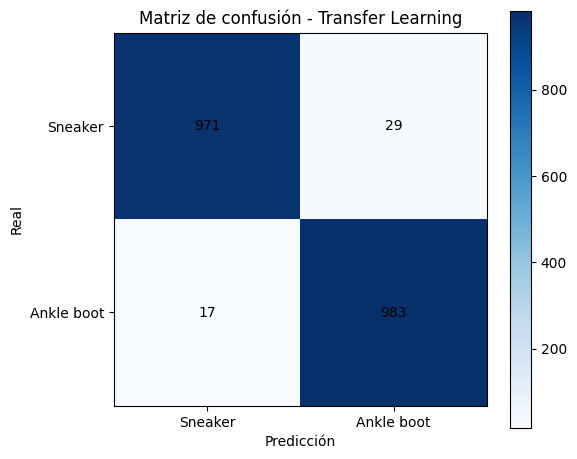

In [71]:
plt.figure(figsize=(6, 5))

plt.imshow(
    cm_tl,
    cmap="Blues"
)

plt.title(
    "Matriz de confusión - Transfer Learning"
)

plt.xlabel(
    "Predicción"
)

plt.ylabel(
    "Real"
)

plt.xticks(
    [0, 1],
    ["Sneaker", "Ankle boot"]
)

plt.yticks(
    [0, 1],
    ["Sneaker", "Ankle boot"]
)

for i in range(2):
    for j in range(2):

        plt.text(
            j,
            i,
            cm_tl[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

## 9. Comparación global

Finalmente, se comparará el rendimiento de los modelos utilizados durante el desarrollo:

- CNN sin Data Augmentation.
- CNN con Data Augmentation.
- Transfer Learning utilizando ResNet18.

La comparación se realizará utilizando las métricas **Accuracy** y **ROC-AUC** sobre el conjunto de prueba.

In [72]:
print("Resumen de resultados en test")

print(
    f"CNN sin augmentation       | "
    f"acc={test_acc_base:.4f} | "
    f"auc={test_auc_base:.4f}"
)

print(
    f"CNN con augmentation       | "
    f"acc={test_acc_aug:.4f} | "
    f"auc={test_auc_aug:.4f}"
)

print(
    f"Transfer Learning (ResNet) | "
    f"acc={test_acc_tl:.4f} | "
    f"auc={test_auc_tl:.4f}"
)

Resumen de resultados en test
CNN sin augmentation       | acc=0.9335 | auc=0.9832
CNN con augmentation       | acc=0.9015 | auc=0.9703
Transfer Learning (ResNet) | acc=0.9770 | auc=0.9975


### 9.1. Análisis de la comparación global

La comparación global muestra diferencias claras entre los tres modelos evaluados.

La **CNN sin Data Augmentation** obtuvo un Accuracy de `0.9335` y un ROC-AUC de `0.9832`.

La **CNN con Data Augmentation** obtuvo un Accuracy de `0.9015` y un ROC-AUC de `0.9703`, por lo que en este caso el aumento de datos no mejoró el rendimiento del modelo.

Por otro lado, el modelo de **Transfer Learning con ResNet18** obtuvo los mejores resultados, con un Accuracy de `0.9770` y un ROC-AUC de `0.9975`.

Estos resultados indican que ResNet18 presentó una mejor capacidad de clasificación y una mejor separación entre las clases Sneaker y Ankle boot.

En comparación con la CNN sin Data Augmentation, ResNet18 mejoró el Accuracy en aproximadamente **4.35 puntos porcentuales** y también obtuvo un ROC-AUC más cercano a `1`.

Por lo tanto, el modelo con **Transfer Learning utilizando ResNet18** fue el modelo con mejor desempeño general en este experimento.

## 10. Interpretabilidad básica: Grad-CAM

Grad-CAM permite visualizar las regiones de una imagen que tuvieron mayor influencia en la predicción realizada por una red neuronal convolucional.

En este caso se utilizará el modelo **ResNet18**, que obtuvo el mejor rendimiento en la comparación global.

El mapa generado permitirá observar qué zonas de una imagen de FashionMNIST fueron consideradas importantes por el modelo para diferenciar entre las clases **Sneaker** y **Ankle boot**.

### 10.1. Función Grad-CAM

In [74]:
import torch

def grad_cam(model, image_tensor, target_class=None):
    model.eval()
    image_tensor = image_tensor.to(device)

    activations = {}
    gradients = {}

    def forward_hook(module, inp, out):
        activations["value"] = out

    def backward_hook(module, grad_in, grad_out):
        gradients["value"] = grad_out[0]

    handle_fwd = model.layer4.register_forward_hook(
        forward_hook
    )

    handle_bwd = model.layer4.register_full_backward_hook(
        backward_hook
    )

    logits = model(
        image_tensor.unsqueeze(0)
    )

    if target_class is None:
        target_class = int(
            torch.argmax(
                logits,
                dim=1
            ).item()
        )

    score = logits[
        0,
        target_class
    ]

    model.zero_grad()

    score.backward()

    act = activations[
        "value"
    ][0]

    grad = gradients[
        "value"
    ][0]

    weights = torch.mean(
        grad,
        dim=(1, 2)
    )

    cam = torch.sum(
        weights[:, None, None] * act,
        dim=0
    )

    cam = torch.relu(cam)

    cam = cam - cam.min()

    cam = cam / (
        cam.max() + 1e-8
    )

    handle_fwd.remove()
    handle_bwd.remove()

    return (
        cam.detach().cpu().numpy(),
        target_class
    )

### 10.2. Visualización del Grad-CAM

Se seleccionará una imagen del conjunto de prueba para observar:

1. La imagen original.
2. El mapa generado por Grad-CAM.
3. La superposición del mapa sobre la imagen original.

Las regiones resaltadas representan las zonas que tuvieron mayor influencia en la predicción realizada por ResNet18.

<sys>:0: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


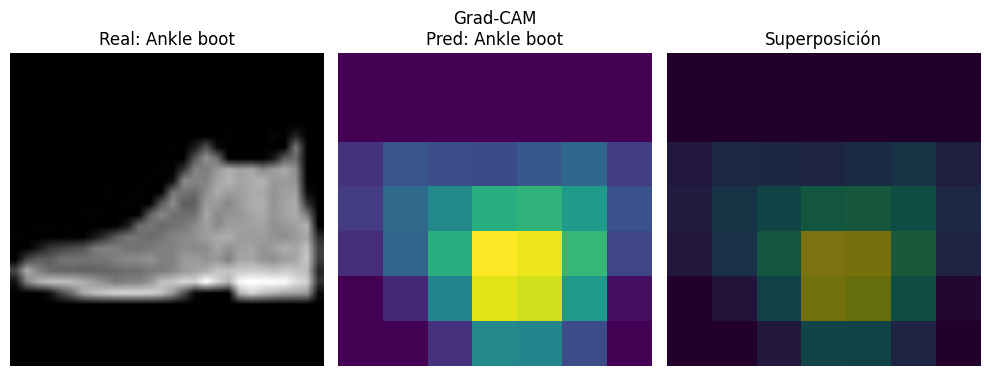

In [75]:
idx = 0

x, y = test_dataset_tl[idx]

cam, pred_class = grad_cam(
    resnet,
    x
)

img = x[0].numpy()

class_names = [
    "Sneaker",
    "Ankle boot"
]

plt.figure(
    figsize=(10, 4)
)


# Imagen original
plt.subplot(1, 3, 1)

plt.imshow(
    img,
    cmap="gray"
)

plt.title(
    f"Real: {class_names[int(y)]}"
)

plt.axis("off")


# Grad-CAM
plt.subplot(1, 3, 2)

plt.imshow(
    cam
)

plt.title(
    f"Grad-CAM\n"
    f"Pred: {class_names[pred_class]}"
)

plt.axis("off")


# Superposición
plt.subplot(1, 3, 3)

plt.imshow(
    img,
    cmap="gray"
)

plt.imshow(
    cam,
    alpha=0.5
)

plt.title(
    "Superposición"
)

plt.axis("off")


plt.tight_layout()

plt.show()

### 10.3. Análisis de Grad-CAM

En el ejemplo analizado, la clase real de la imagen corresponde a **Ankle boot** y el modelo ResNet18 realizó correctamente la misma predicción.

El mapa Grad-CAM muestra que las regiones con mayor activación se concentran principalmente en la zona central e inferior del calzado. Estas áreas contienen características relacionadas con la forma y estructura de la bota, las cuales influyeron en la decisión del modelo.

En la superposición se puede observar que ResNet18 no utiliza toda la imagen con la misma importancia, sino que concentra su atención en determinadas regiones del objeto para realizar la clasificación.

Por lo tanto, Grad-CAM permite visualizar de manera aproximada qué zonas de la imagen fueron más relevantes para que el modelo identificara correctamente la clase **Ankle boot**.

## 11. Buenas prácticas

Durante el desarrollo de modelos de clasificación de imágenes es importante considerar algunas buenas prácticas:

1. **Separar correctamente los datos de entrenamiento, validación y prueba**, evitando que el modelo utilice información del conjunto de prueba durante el entrenamiento.

2. **Utilizar diferentes métricas de evaluación**, ya que Accuracy por sí sola no siempre permite analizar completamente el comportamiento del modelo. En este trabajo también se utilizaron ROC-AUC, Precision, Recall, F1-score y matriz de confusión.

3. **Evitar el sobreajuste**, utilizando conjuntos de validación y técnicas como Data Augmentation cuando sean apropiadas.

4. **Comparar diferentes modelos**, como una CNN entrenada desde cero y un modelo preentrenado mediante Transfer Learning.

5. **Utilizar herramientas de interpretabilidad**, como Grad-CAM, para observar qué regiones de la imagen influyen en las predicciones del modelo.

6. **Mantener reproducibilidad**, registrando los hiperparámetros utilizados y guardando los modelos entrenados.

## 12. Guardar y cargar modelos

Guardar los modelos entrenados permite reutilizarlos posteriormente sin necesidad de volver a realizar todo el entrenamiento.

Se guardarán los pesos de:

- CNN sin Data Augmentation.
- CNN con Data Augmentation.
- ResNet18 con Transfer Learning.

In [76]:
import os

os.makedirs(
    "models",
    exist_ok=True
)

torch.save(
    model_scratch.state_dict(),
    "models/cnn_scratch.pth"
)

torch.save(
    model_aug.state_dict(),
    "models/cnn_aug.pth"
)

torch.save(
    resnet.state_dict(),
    "models/resnet_transfer.pth"
)

[
    "models/cnn_scratch.pth",
    "models/cnn_aug.pth",
    "models/resnet_transfer.pth"
]

['models/cnn_scratch.pth', 'models/cnn_aug.pth', 'models/resnet_transfer.pth']

## 13. Conclusiones

Durante el desarrollo se evaluaron diferentes configuraciones de redes neuronales convolucionales para clasificar imágenes de FashionMNIST correspondientes a las clases **Sneaker** y **Ankle boot**.

La CNN original obtuvo un buen desempeño, mientras que la incorporación de Dropout no produjo una mejora significativa en esta ejecución. También se probaron diferentes valores de learning rate y el uso de un scheduler, observándose que `LR = 0.001` presentó el mejor equilibrio entre pérdida de validación y ROC-AUC.

En el experimento de Data Augmentation, el modelo sin aumento de datos obtuvo mejores resultados que el modelo con rotaciones y traslaciones. La CNN sin Data Augmentation alcanzó un **Accuracy de 0.9335** y un **ROC-AUC de 0.9832**, mientras que la CNN con Data Augmentation obtuvo un Accuracy de `0.9015` y un ROC-AUC de `0.9703`.

Posteriormente, se utilizó Transfer Learning con **ResNet18** preentrenada en ImageNet. Después del entrenamiento de la capa final y del Fine-tuning, ResNet18 obtuvo un **Accuracy de 0.9770** y un **ROC-AUC de 0.9975**, superando a las CNN entrenadas desde cero.

Por lo tanto, **ResNet18 fue el modelo con mejor desempeño general**, mostrando una alta capacidad para clasificar y diferenciar las clases Sneaker y Ankle boot.

Finalmente, mediante **Grad-CAM** se pudo visualizar qué regiones de una imagen influyeron en la predicción de ResNet18. Esto permitió complementar las métricas numéricas con una interpretación visual del comportamiento del modelo.

En conjunto, los experimentos mostraron que tanto la arquitectura utilizada como los hiperparámetros, el aumento de datos y el uso de modelos preentrenados pueden influir directamente en el rendimiento de un modelo de clasificación de imágenes.